# Modelización — Dataset de Intenciones (Fonazo)

Clasificación de intención de mensajes de clientes (8 clases) sobre el corpus Fonazo (96 muestras).

In [1]:
import joblib
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneOut, cross_val_predict, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Carga de datos

In [2]:
df = pd.read_csv('../../data/intenciones_dataset.csv')
print(df.shape)
print(df['intencion'].value_counts())
df.head(5)

(96, 2)
intencion
consulta_producto            12
consulta_precio              12
consulta_servicio_tecnico    12
seguimiento_reparacion       12
queja_producto_servicio      12
solicitud_garantia_cambio    12
saludo_cierre                12
escalamiento_urgente         12
Name: count, dtype: int64


,texto,intencion
0,¿Tienen el iPhone 15 Pro en 256GB?,consulta_producto
1,¿Tienen stock del 16 Pro Max?,consulta_producto
2,¿Le hace al iPhone 13 el case MagSafe?,consulta_producto
3,¿En qué colores tienen el iPhone 16?,consulta_producto
4,Hola ¿tienen el 11 reacondicionado?,consulta_producto


## 2. Preprocesamiento de texto

In [3]:
STOPWORDS_ES = {
    'de','la','el','en','y','a','que','los','se','del','las','un','por',
    'una','con','no','es','su','al','lo','mas','pero','si','como','me',
    'le','mi','muy','este','esta','ya','tambien','hay','para','son','fue',
    'todo','bien','cuando','sobre','sin','han','he','o','e','ni',
    'era','ser','tiene','habia','sus','mismo','tan','asi',
    'unos','desde','porque','hasta','te','les','nos','yo','tu','tus'
}

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-zñáéíóú ]', ' ', texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return ' '.join(palabras)

df['texto_limpio'] = df['texto'].apply(limpiar_texto)
df[['texto', 'texto_limpio', 'intencion']].head(5)

,texto,texto_limpio,intencion
0,¿Tienen el iPhone 15 Pro en 256GB?,tienen iphone pro,consulta_producto
1,¿Tienen stock del 16 Pro Max?,tienen stock pro max,consulta_producto
2,¿Le hace al iPhone 13 el case MagSafe?,hace iphone case magsafe,consulta_producto
3,¿En qué colores tienen el iPhone 16?,qué colores tienen iphone,consulta_producto
4,Hola ¿tienen el 11 reacondicionado?,hola tienen reacondicionado,consulta_producto


## 3. Vectorización TF-IDF

Dado el vocabulario reducido (255 palabras únicas), se usa un espacio de características más pequeño que en el dataset de Amazon.

In [4]:
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=1)
X = vectorizer.fit_transform(df['texto_limpio'])
# Se fuerza a numpy array de tipo objeto: pandas 3.x usa backend pyarrow para strings
# por defecto, y ese tipo no es compatible con la indexación fancy que usa scikit-learn
# en cross_val_predict / LeaveOneOut.
y = df['intencion'].astype(str).to_numpy(dtype=object)
print('Dimensión de la matriz TF-IDF:', X.shape)

Dimensión de la matriz TF-IDF: (96, 500)


## 4. Clasificador basado en reglas / diccionario (baseline)

Se construye un baseline heurístico a partir de los tokens distintivos por clase identificados en el EDA (Hallazgo de tokens frecuentes por intención).

In [5]:
DICCIONARIO_INTENCION = {
    'consulta_producto': ['tienen', 'iphone', 'pro', 'magsafe', 'disponible', 'stock', 'modelo'],
    'consulta_precio': ['cuesta', 'precio', 'cuanto', 'vale', 'oferta', 'descuento'],
    'consulta_servicio_tecnico': ['servicio', 'tecnico', 'pantalla', 'bateria', 'arreglo', 'reparar'],
    'seguimiento_reparacion': ['reparacion', 'estado', 'demora', 'orden', 'listo', 'seguimiento'],
    'queja_producto_servicio': ['defectuoso', 'malo', 'falla', 'queja', 'devolucion', 'rajada', 'quiñada'],
    'solicitud_garantia_cambio': ['cambio', 'garantia', 'defecto', 'nuevo', 'reemplazo'],
    'saludo_cierre': ['hola', 'gracias', 'buenas', 'saludos', 'adios'],
    'escalamiento_urgente': ['urge', 'inmediato', 'ayuda', 'urgente', 'ya']
}

class ClasificadorReglas(BaseEstimator, ClassifierMixin):
    """Clasificador heurístico por conteo de coincidencias de palabras clave por clase."""

    def __init__(self, diccionario):
        self.diccionario = diccionario

    def fit(self, X, y):
        self.clase_default_ = pd.Series(y).mode()[0]
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        predicciones = []
        for texto in X:
            texto = str(texto)
            puntajes = {clase: sum(1 for kw in kws if kw in texto) for clase, kws in self.diccionario.items()}
            mejor = max(puntajes, key=puntajes.get)
            predicciones.append(mejor if puntajes[mejor] > 0 else self.clase_default_)
        return np.array(predicciones)

## 5. Entrenamiento y evaluación con Leave-One-Out Cross-Validation

Dado el reducido tamaño del dataset (96 muestras), se usa LOOCV para maximizar el uso de los datos y obtener una estimación robusta del rendimiento.

In [6]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes Multinomial': MultinomialNB(),
    'SVM Lineal': LinearSVC(random_state=RANDOM_STATE),
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3, metric='cosine'),
}

loo = LeaveOneOut()
resultados_loo = []
predicciones_loo = {}

for nombre, modelo in modelos.items():
    t0 = time.time()
    y_pred = cross_val_predict(modelo, X, y, cv=loo, n_jobs=-1)
    tiempo = time.time() - t0
    resultados_loo.append({
        'Modelo': nombre,
        'Accuracy (LOOCV)': accuracy_score(y, y_pred),
        'F1-macro (LOOCV)': f1_score(y, y_pred, average='macro'),
        'Tiempo (s)': round(tiempo, 1)
    })
    predicciones_loo[nombre] = y_pred
    print(f'{nombre}: listo en {tiempo:.1f}s')

# Clasificador basado en reglas (no requiere entrenamiento estadístico, se evalúa directo)
clf_reglas = ClasificadorReglas(DICCIONARIO_INTENCION).fit(df['texto_limpio'].values, y)
y_pred_reglas = clf_reglas.predict(df['texto_limpio'].values)
resultados_loo.append({
    'Modelo': 'Reglas + Diccionario',
    'Accuracy (LOOCV)': accuracy_score(y, y_pred_reglas),
    'F1-macro (LOOCV)': f1_score(y, y_pred_reglas, average='macro'),
    'Tiempo (s)': 0.0
})
predicciones_loo['Reglas + Diccionario'] = y_pred_reglas

df_resultados = pd.DataFrame(resultados_loo).sort_values('F1-macro (LOOCV)', ascending=False).reset_index(drop=True)
df_resultados

Regresión Logística: listo en 5.5s
Naive Bayes Multinomial: listo en 0.1s


SVM Lineal: listo en 0.1s


k-NN (k=3): listo en 0.3s


,Modelo,Accuracy (LOOCV),F1-macro (LOOCV),Tiempo (s)
0,SVM Lineal,0.510417,0.498692,0.1
1,k-NN (k=3),0.416667,0.411592,0.3
2,Regresión Logística,0.416667,0.404398,5.5
3,Naive Bayes Multinomial,0.416667,0.394996,0.1
4,Reglas + Diccionario,0.312500,0.255716,0.0


## 6. Validación cruzada estratificada (5 pliegues) — comparación

Se reporta también con 5-fold estratificado para contrastar contra LOOCV.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_5f = []

for nombre, modelo in modelos.items():
    y_pred = cross_val_predict(modelo, X, y, cv=skf, n_jobs=-1)
    resultados_5f.append({
        'Modelo': nombre,
        'Accuracy (5-fold)': accuracy_score(y, y_pred),
        'F1-macro (5-fold)': f1_score(y, y_pred, average='macro')
    })

df_5f = pd.DataFrame(resultados_5f)
df_5f

,Modelo,Accuracy (5-fold),F1-macro (5-fold)
0,Regresión Logística,0.468750,0.460056
1,Naive Bayes Multinomial,0.458333,0.445945
2,SVM Lineal,0.500000,0.489043
3,k-NN (k=3),0.447917,0.428952


## 7. Matrices de confusión (mejor modelo)

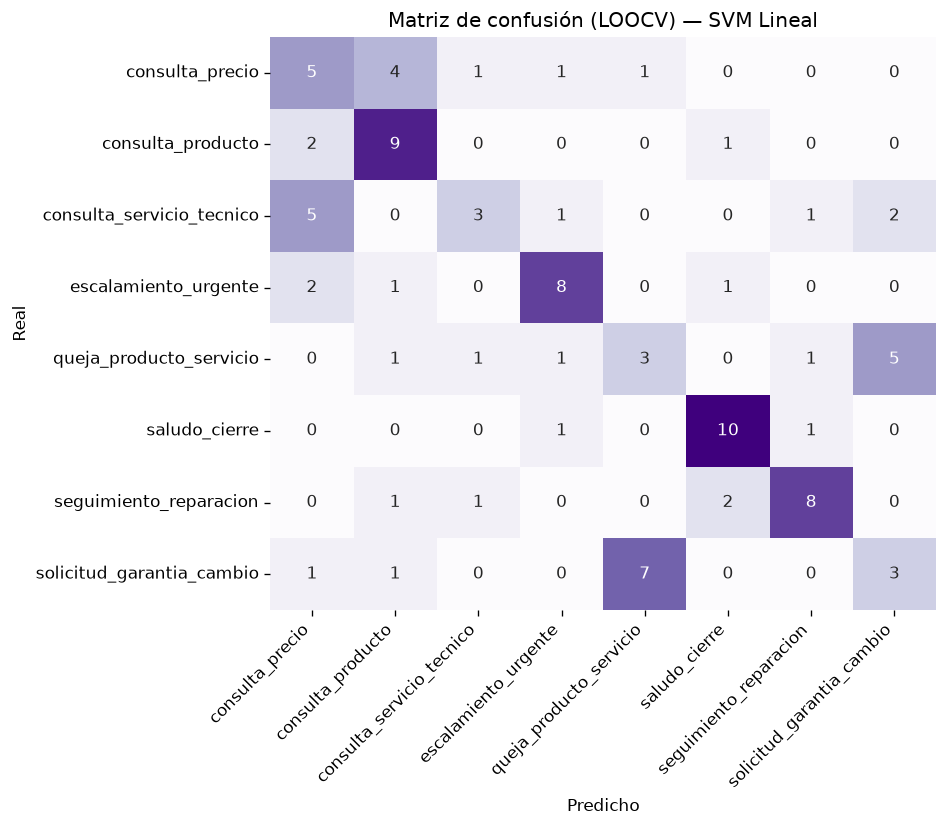

                           precision    recall  f1-score   support

          consulta_precio       0.33      0.42      0.37        12
        consulta_producto       0.53      0.75      0.62        12
consulta_servicio_tecnico       0.50      0.25      0.33        12
     escalamiento_urgente       0.67      0.67      0.67        12
  queja_producto_servicio       0.27      0.25      0.26        12
            saludo_cierre       0.71      0.83      0.77        12
   seguimiento_reparacion       0.73      0.67      0.70        12
solicitud_garantia_cambio       0.30      0.25      0.27        12

                 accuracy                           0.51        96
                macro avg       0.51      0.51      0.50        96
             weighted avg       0.51      0.51      0.50        96



In [8]:
mejor_modelo = df_resultados.iloc[0]['Modelo']
y_pred_mejor = predicciones_loo[mejor_modelo]

fig, ax = plt.subplots(figsize=(8, 7))
clases_orden = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred_mejor, labels=clases_orden)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=clases_orden, yticklabels=clases_orden)
ax.set_title(f'Matriz de confusión (LOOCV) — {mejor_modelo}')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../resultados/figuras/fig11_matriz_confusion_fonazo.png', bbox_inches='tight')
plt.show()

print(classification_report(y, y_pred_mejor))

## 8. Comparación gráfica de modelos

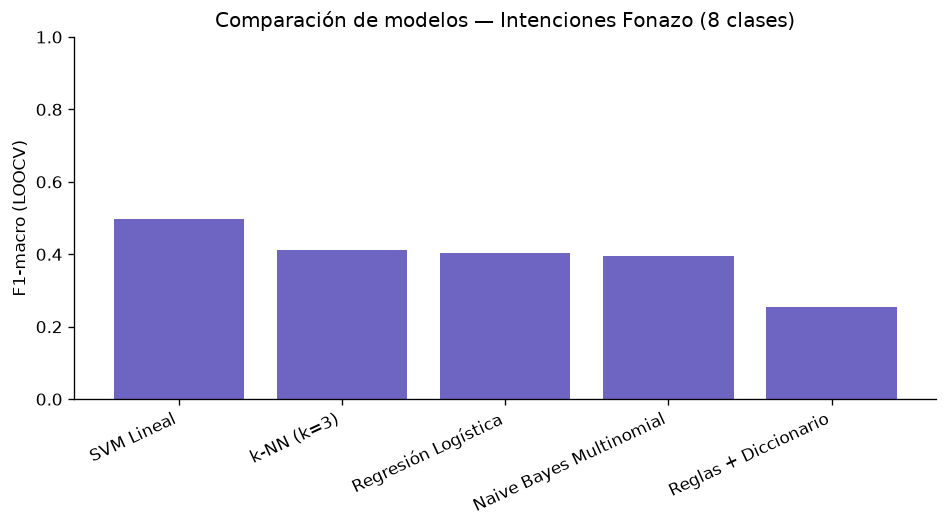

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(df_resultados['Modelo'], df_resultados['F1-macro (LOOCV)'], color='#534AB7', alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-macro (LOOCV)')
ax.set_title('Comparación de modelos — Intenciones Fonazo (8 clases)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig12_comparacion_modelos_fonazo.png', bbox_inches='tight')
plt.show()

## 9. Exportar resultados

In [10]:
df_resultados.to_csv('../resultados/tablas/resultados_fonazo.csv', index=False)
df_5f.to_csv('../resultados/tablas/resultados_5fold_fonazo.csv', index=False)
print('Resultados guardados: resultados_fonazo.csv, resultados_5fold_fonazo.csv')

Resultados guardados: resultados_fonazo.csv, resultados_5fold_fonazo.csv


## 10. Dataset aumentado — comparación antes / después

Dado el bajo rendimiento con las 96 muestras originales (limitación esperada por tamaño de dataset), se amplió el corpus a 296 mensajes mediante variaciones controladas por clase (mismo vocabulario de dominio, mayor diversidad léxica y sintáctica). Se repite el mismo protocolo de evaluación (LOOCV) para comparar el efecto del aumento de datos.

In [11]:
df_aum = pd.read_csv('../../data/intenciones_dataset_aumentado.csv')
df_aum['texto_limpio'] = df_aum['texto'].apply(limpiar_texto)
print(df_aum.shape)
df_aum['intencion'].value_counts()

(296, 3)


intencion
consulta_producto            37
consulta_precio              37
consulta_servicio_tecnico    37
seguimiento_reparacion       37
queja_producto_servicio      37
solicitud_garantia_cambio    37
saludo_cierre                37
escalamiento_urgente         37
Name: count, dtype: int64

In [12]:
vectorizer_aum = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=1)
X_aum = vectorizer_aum.fit_transform(df_aum['texto_limpio'])
y_aum = df_aum['intencion'].astype(str).to_numpy(dtype=object)
print('Dimensión TF-IDF (aumentado):', X_aum.shape)

resultados_aum = []
predicciones_aum = {}

for nombre, modelo in modelos.items():
    t0 = time.time()
    y_pred = cross_val_predict(modelo, X_aum, y_aum, cv=loo, n_jobs=-1)
    tiempo = time.time() - t0
    resultados_aum.append({
        'Modelo': nombre,
        'Accuracy (LOOCV)': accuracy_score(y_aum, y_pred),
        'F1-macro (LOOCV)': f1_score(y_aum, y_pred, average='macro'),
        'Tiempo (s)': round(tiempo, 1)
    })
    predicciones_aum[nombre] = y_pred
    print(f'{nombre}: listo en {tiempo:.1f}s')

clf_reglas_aum = ClasificadorReglas(DICCIONARIO_INTENCION).fit(df_aum['texto_limpio'].values, y_aum)
y_pred_reglas_aum = clf_reglas_aum.predict(df_aum['texto_limpio'].values)
resultados_aum.append({
    'Modelo': 'Reglas + Diccionario',
    'Accuracy (LOOCV)': accuracy_score(y_aum, y_pred_reglas_aum),
    'F1-macro (LOOCV)': f1_score(y_aum, y_pred_reglas_aum, average='macro'),
    'Tiempo (s)': 0.0
})

df_resultados_aum = pd.DataFrame(resultados_aum).sort_values('F1-macro (LOOCV)', ascending=False).reset_index(drop=True)
df_resultados_aum

Dimensión TF-IDF (aumentado): (296, 1000)


Regresión Logística: listo en 1.8s


Naive Bayes Multinomial: listo en 0.3s


SVM Lineal: listo en 0.5s


k-NN (k=3): listo en 0.3s


,Modelo,Accuracy (LOOCV),F1-macro (LOOCV),Tiempo (s)
0,SVM Lineal,0.787162,0.782870,0.5
1,Regresión Logística,0.746622,0.744293,1.8
2,Naive Bayes Multinomial,0.733108,0.721591,0.3
3,k-NN (k=3),0.635135,0.630038,0.3
4,Reglas + Diccionario,0.347973,0.345534,0.0


### Comparación antes (96 muestras) vs. después (296 muestras)

In [13]:
comparacion = df_resultados.set_index('Modelo')[['F1-macro (LOOCV)']].rename(columns={'F1-macro (LOOCV)': 'F1-macro (96 muestras)'})
comparacion = comparacion.join(
    df_resultados_aum.set_index('Modelo')[['F1-macro (LOOCV)']].rename(columns={'F1-macro (LOOCV)': 'F1-macro (296 muestras)'})
)
comparacion['Mejora (puntos)'] = comparacion['F1-macro (296 muestras)'] - comparacion['F1-macro (96 muestras)']
comparacion = comparacion.sort_values('F1-macro (296 muestras)', ascending=False)
comparacion

,F1-macro (96 muestras),F1-macro (296 muestras),Mejora (puntos)
Modelo,,,
SVM Lineal,0.498692,0.782870,0.284178
Regresión Logística,0.404398,0.744293,0.339895
Naive Bayes Multinomial,0.394996,0.721591,0.326595
k-NN (k=3),0.411592,0.630038,0.218446
Reglas + Diccionario,0.255716,0.345534,0.089818


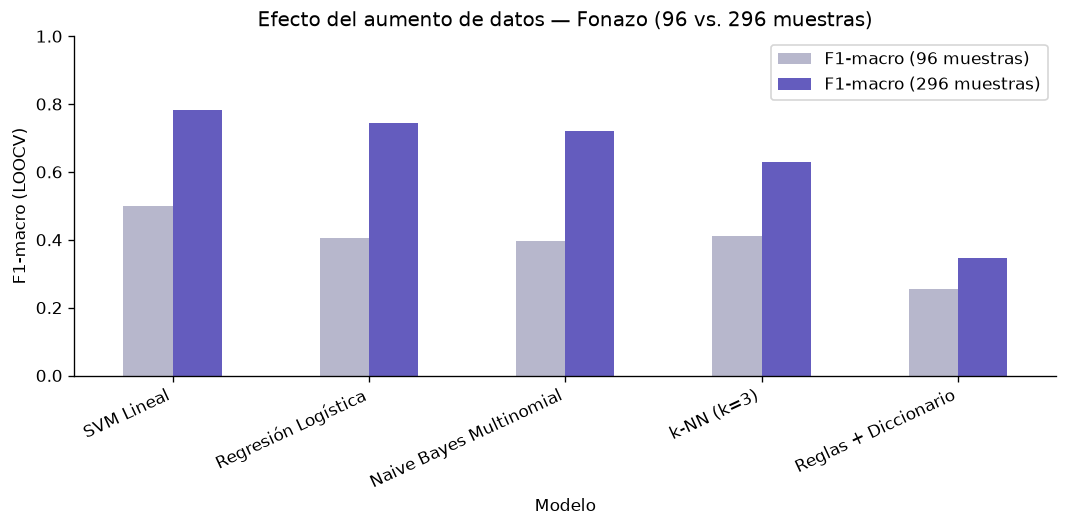

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
comparacion[['F1-macro (96 muestras)', 'F1-macro (296 muestras)']].plot(kind='bar', ax=ax, color=['#B0AFC7', '#534AB7'], alpha=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-macro (LOOCV)')
ax.set_title('Efecto del aumento de datos — Fonazo (96 vs. 296 muestras)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig13_comparacion_aumento_datos_fonazo.png', bbox_inches='tight')
plt.show()

In [15]:
df_resultados_aum.to_csv('../resultados/tablas/resultados_fonazo_aumentado.csv', index=False)
comparacion.to_csv('../resultados/tablas/comparacion_fonazo_antes_despues.csv')
print('Resultados guardados: resultados_fonazo_aumentado.csv, comparacion_fonazo_antes_despues.csv')

Resultados guardados: resultados_fonazo_aumentado.csv, comparacion_fonazo_antes_despues.csv


## 11. Curvas de aprendizaje (dataset aumentado, train vs. cross-validation)

Se evalua el efecto del tamano de muestra sobre el desempeno usando el dataset ampliado (296 mensajes), donde ya es posible construir una curva de aprendizaje informativa (con las 96 muestras originales el rango de tamanos posibles era demasiado estrecho).

Regresión Logística

 : listo en 0.2 s
Naive Bayes Multinomial : listo en 0.1 s
SVM Lineal : listo en 0.1 s


k-NN (k=3) : listo en 0.1 s


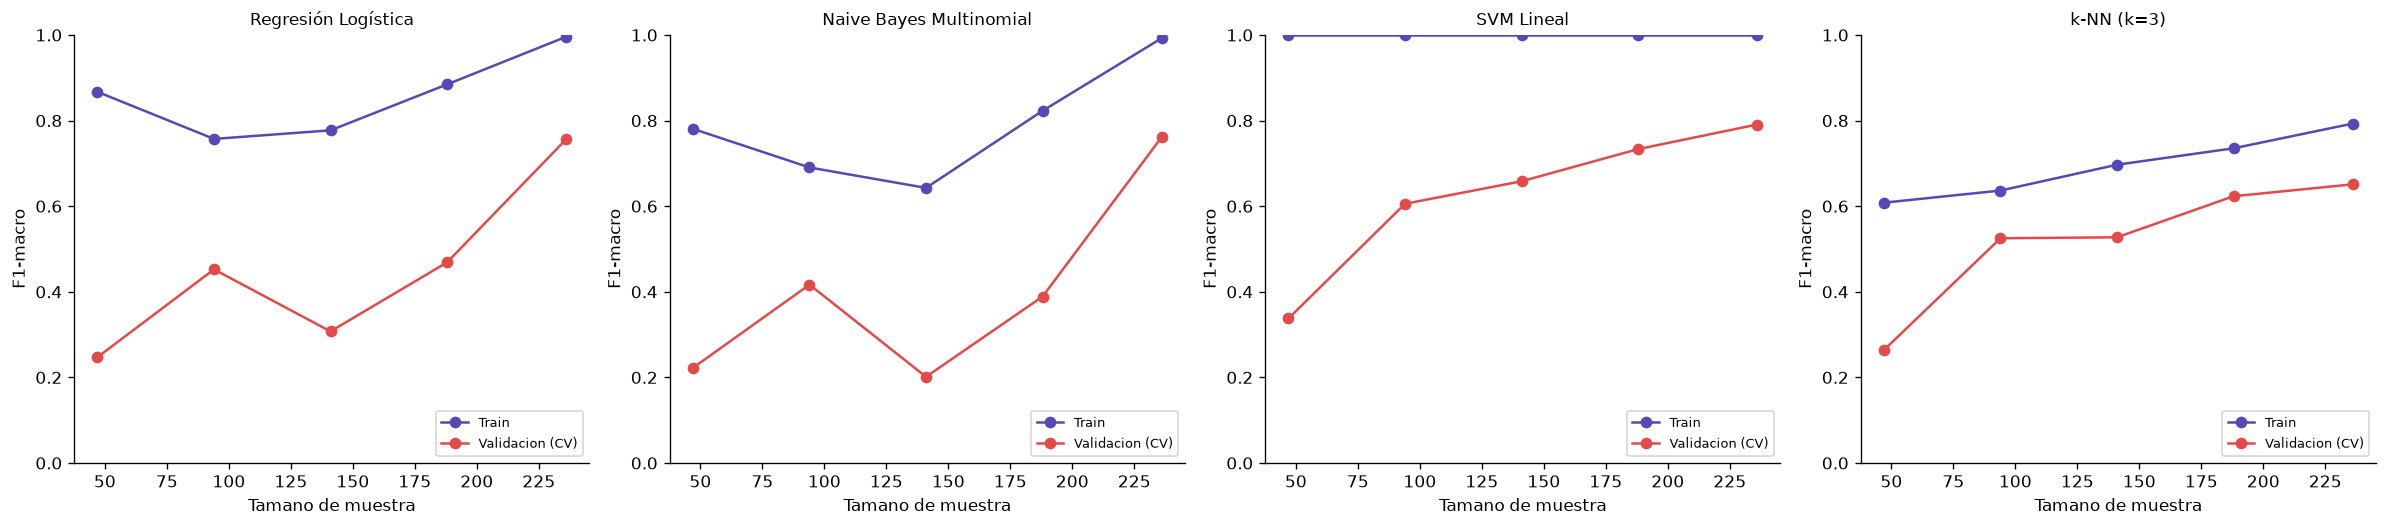

In [16]:
train_sizes_fz = np.linspace(0.2, 1.0, 5)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    t0 = time.time()
    sizes, train_scores, val_scores = learning_curve(
        modelo, X_aum, y_aum, train_sizes=train_sizes_fz, cv=5,
        scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE
    )
    ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='#534AB7', label='Train')
    ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='#E24B4A', label='Validacion (CV)')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Tamano de muestra')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, 1.0)
    ax.legend(loc='lower right', fontsize=8)
    print(nombre, ': listo en', round(time.time()-t0, 1), 's')

plt.tight_layout()
plt.savefig('../resultados/figuras/fig17_curvas_aprendizaje_fonazo.png', bbox_inches='tight')
plt.show()

## 12. Fine-tuning de BETO sobre el dataset aumentado (296 muestras, 8 clases)

A diferencia de los modelos anteriores, aquí no se usa LOOCV: fine-tunear un transformer 296 veces (una por muestra) es computacionalmente inviable. Se usa en su lugar una división train/test estratificada (80/20). Dado que el corpus sigue siendo muy pequeño para un transformer (que normalmente requiere miles de ejemplos), se espera como hallazgo posible que BETO **no** supere a los modelos clásicos aquí — lo cual, de confirmarse, refuerza la conclusión de que el cuello de botella es el volumen de datos y no el algoritmo.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.preprocessing import LabelEncoder

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

le = LabelEncoder()
y_aum_enc = le.fit_transform(y_aum)
NUM_CLASES = len(le.classes_)
print('Clases:', list(le.classes_))

X_train_txt, X_test_txt, y_train_fz, y_test_fz = train_test_split(
    df_aum['texto'].astype(str).tolist(), y_aum_enc,
    test_size=0.2, stratify=y_aum_enc, random_state=RANDOM_STATE
)
print('Train:', len(X_train_txt), '| Test:', len(X_test_txt))

Device: cuda
Clases: ['consulta_precio', 'consulta_producto', 'consulta_servicio_tecnico', 'escalamiento_urgente', 'queja_producto_servicio', 'saludo_cierre', 'seguimiento_reparacion', 'solicitud_garantia_cambio']
Train: 236 | Test: 60


In [18]:
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
MAX_LEN = 48

tokenizer_fz = AutoTokenizer.from_pretrained(MODEL_NAME)
enc_train_fz = tokenizer_fz(X_train_txt, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')
enc_test_fz = tokenizer_fz(X_test_txt, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='pt')

class IntencionesDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds_fz = IntencionesDataset(enc_train_fz, y_train_fz)
test_ds_fz = IntencionesDataset(enc_test_fz, y_test_fz)

train_loader_fz = DataLoader(train_ds_fz, batch_size=8, shuffle=True)
test_loader_fz = DataLoader(test_ds_fz, batch_size=16, shuffle=False)
print('Batches de entrenamiento:', len(train_loader_fz))

Batches de entrenamiento: 30


In [19]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

model_fz = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASES).to(DEVICE)
loss_fn_fz = nn.CrossEntropyLoss()
optimizer_fz = torch.optim.AdamW(model_fz.parameters(), lr=3e-5)
scaler_fz = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

def evaluar_fz(loader):
    model_fz.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                outputs = model_fz(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
                loss = loss_fn_fz(outputs.logits, batch['labels'])
            total_loss += loss.item()
            all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    model_fz.train()
    return total_loss / len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='macro')

EPOCHS_FZ = 15
historia_fz = []
model_fz.train()
t0 = time.time()

for epoch in range(EPOCHS_FZ):
    epoch_loss = 0.0
    for batch in train_loader_fz:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer_fz.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            outputs = model_fz(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            loss = loss_fn_fz(outputs.logits, batch['labels'])
        scaler_fz.scale(loss).backward()
        scaler_fz.step(optimizer_fz)
        scaler_fz.update()
        epoch_loss += loss.item()

    train_loss_avg = epoch_loss / len(train_loader_fz)
    tr_loss, tr_acc, tr_f1 = evaluar_fz(train_loader_fz)
    te_loss, te_acc, te_f1 = evaluar_fz(test_loader_fz)
    historia_fz.append({
        'epoch': epoch + 1, 'train_loss': train_loss_avg,
        'train_acc': tr_acc, 'train_f1': tr_f1,
        'test_loss': te_loss, 'test_acc': te_acc, 'test_f1': te_f1
    })
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_FZ} | Train F1: {tr_f1:.3f} | Test F1: {te_f1:.3f}')

print(f'Fine-tuning completado en {(time.time()-t0)/60:.1f} min')
df_historia_fz = pd.DataFrame(historia_fz)
df_historia_fz.to_csv('../resultados/tablas/historia_entrenamiento_beto_fonazo.csv', index=False)
df_historia_fz.tail()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch 1/15 | Train F1: 0.770 | Test F1: 0.554


Epoch 3/15 | Train F1: 0.996 | Test F1: 0.835


Epoch 6/15 | Train F1: 1.000 | Test F1: 0.851


Epoch 9/15 | Train F1: 1.000 | Test F1: 0.871


Epoch 12/15 | Train F1: 1.000 | Test F1: 0.871


Epoch 15/15 | Train F1: 1.000 | Test F1: 0.887
Fine-tuning completado en 1.0 min


,epoch,train_loss,train_acc,train_f1,test_loss,test_acc,test_f1
10,11,0.011195,1.0,1.0,0.461208,0.866667,0.870756
11,12,0.009864,1.0,1.0,0.461206,0.866667,0.870756
12,13,0.008861,1.0,1.0,0.463191,0.866667,0.870756
13,14,0.007903,1.0,1.0,0.471414,0.866667,0.870756
14,15,0.007322,1.0,1.0,0.479956,0.883333,0.887423


### Curva de aprendizaje de BETO en Fonazo (train vs. test por época)

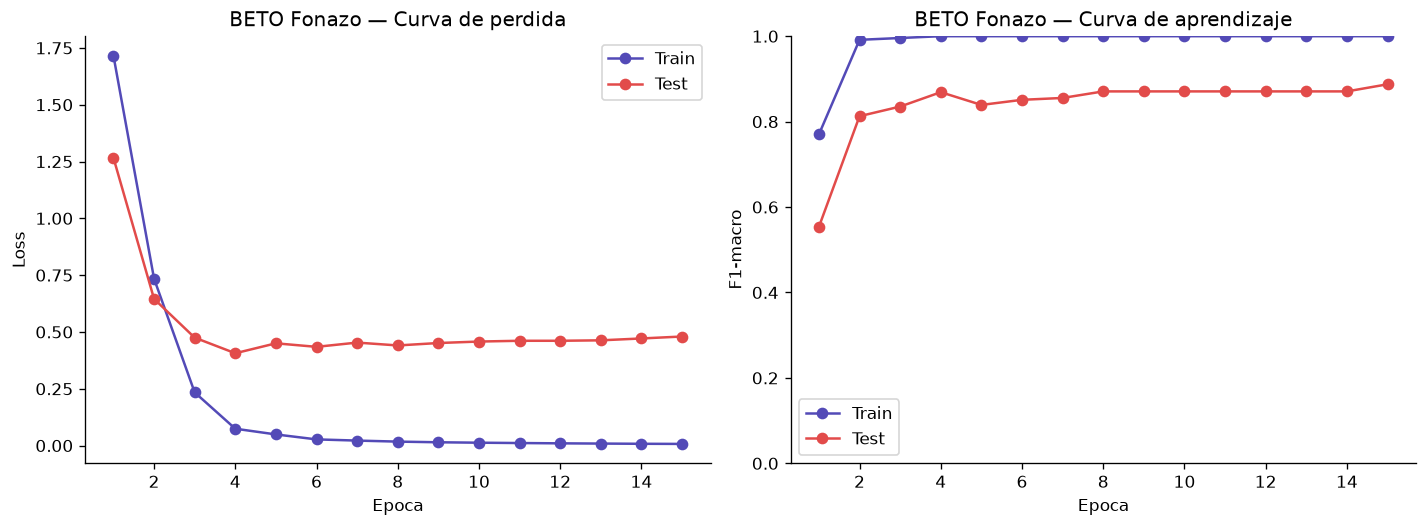

{'Modelo': 'BETO (fine-tuned)', 'Accuracy (train/test 80-20)': np.float64(0.8833333333333333), 'F1-macro (train/test 80-20)': np.float64(0.8874230140774259)}


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_historia_fz['epoch'], df_historia_fz['train_loss'], 'o-', color='#534AB7', label='Train')
axes[0].plot(df_historia_fz['epoch'], df_historia_fz['test_loss'], 'o-', color='#E24B4A', label='Test')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('BETO Fonazo — Curva de perdida')
axes[0].legend()

axes[1].plot(df_historia_fz['epoch'], df_historia_fz['train_f1'], 'o-', color='#534AB7', label='Train')
axes[1].plot(df_historia_fz['epoch'], df_historia_fz['test_f1'], 'o-', color='#E24B4A', label='Test')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('F1-macro')
axes[1].set_title('BETO Fonazo — Curva de aprendizaje')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('../resultados/figuras/fig18_curva_aprendizaje_beto_fonazo.png', bbox_inches='tight')
plt.show()

resultado_beto_fz = {
    'Modelo': 'BETO (fine-tuned)',
    'Accuracy (train/test 80-20)': df_historia_fz.iloc[-1]['test_acc'],
    'F1-macro (train/test 80-20)': df_historia_fz.iloc[-1]['test_f1'],
}
print(resultado_beto_fz)

In [21]:
comparacion_final_fz = df_resultados_aum[['Modelo', 'F1-macro (LOOCV)']].copy()
comparacion_final_fz = comparacion_final_fz.rename(columns={'F1-macro (LOOCV)': 'F1-macro'})
comparacion_final_fz = pd.concat([
    comparacion_final_fz,
    pd.DataFrame([{'Modelo': 'BETO (fine-tuned, train/test)', 'F1-macro': df_historia_fz.iloc[-1]['test_f1']}])
], ignore_index=True).sort_values('F1-macro', ascending=False).reset_index(drop=True)
comparacion_final_fz.to_csv('../resultados/tablas/comparacion_final_fonazo_con_beto.csv', index=False)
comparacion_final_fz

,Modelo,F1-macro
0,"BETO (fine-tuned, train/test)",0.887423
1,SVM Lineal,0.782870
2,Regresión Logística,0.744293
3,Naive Bayes Multinomial,0.721591
4,k-NN (k=3),0.630038
5,Reglas + Diccionario,0.345534


## 13. Guardar modelo fine-tuneado (para la app de stakeholders)

Se persisten los pesos, el tokenizer y el LabelEncoder (necesario para traducir las predicciones numericas de vuelta a los nombres de intencion). Estos pesos NO se suben a GitHub.

In [22]:
import os
OUT_DIR = '../app/modelos/beto_fonazo'
os.makedirs(OUT_DIR, exist_ok=True)
model_fz.save_pretrained(OUT_DIR)
tokenizer_fz.save_pretrained(OUT_DIR)
joblib.dump(le, f'{OUT_DIR}/label_encoder.joblib')
print('BETO Fonazo guardado en', OUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BETO Fonazo guardado en ../app/modelos/beto_fonazo
